# 실습 3-1 : Random Forest

#### **<실습 내용>**

1. 실습 데이터 탐색 및 전처리
- 분류 데이터 (MachineFailure)
- 회귀 데이터 (Concrete)

2. Random Forest Classifier
- 모델 학습 및 성능 평가
- 변수 중요도 시각화

3. Random Forest Regressor
- 모델 학습 및 성능 평가
- 변수 중요도 시각화

4. 하이퍼 파라미터 최적화
- GridSearchCV를 활용한 최적 파라미터 탐색

## 분석 준비

### 주요 라이브러리 호출

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ===== 한글 폰트 설정 =====
FONT_CANDIDATES = [
    "/System/Library/Fonts/AppleSDGothicNeo.ttc",
    "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
    "C:/Windows/Fonts/malgun.ttf",
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
]
FONT_PATH = next((p for p in FONT_CANDIDATES if os.path.exists(p)), None)
if FONT_PATH:
    fm.fontManager.addfont(FONT_PATH)
    KOREAN_FONT = fm.FontProperties(fname=FONT_PATH)
    rcParams["font.family"] = KOREAN_FONT.get_name()
else:
    KOREAN_FONT = None

rcParams["axes.unicode_minus"] = False

---

## 1) 분류 문제

In [20]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-1_cls_data.csv"))
MF_Data.head()

,Temperature,Humidity,Operator,Measure1,Measure2,Measure3,Measure4,Measure5,Measure6,Measure7,Measure8,Measure9,Measure10,Measure11,Measure12,Measure13,Measure14,Measure15,Hours Since Previous Failure,Failure
0,67,82,Operator1,291,1,1,1041,846,334,706,1086,256,1295,766,968,1185,1355,1842,90,No
1,68,77,Operator1,1180,1,1,1915,1194,637,1093,524,919,245,403,723,1446,719,748,91,No
2,64,76,Operator1,1406,1,1,511,1577,1121,1948,1882,1301,273,1927,1123,717,1518,1689,92,No
3,63,80,Operator1,550,1,1,1754,1834,1413,1151,945,1312,1494,1755,1434,502,1336,711,93,No
4,65,81,Operator1,1928,1,2,1326,1082,233,1441,1736,1033,1549,802,1819,1616,1507,507,94,No


In [21]:
print("데이터 크기 :", MF_Data.shape)
print("출력변수 분포:")
print(MF_Data["Failure"].value_counts())

데이터 크기 : (7900, 20)
출력변수 분포:
Failure
No     7825
Yes      75
Name: count, dtype: int64


In [22]:
# 입출력 변수 분할
Y_cls = MF_Data["Failure"]
X_cls = MF_Data.drop(["Failure"], axis=1)

# 범주형 변수 처리
X_cls["Measure2"] = X_cls["Measure2"].astype("category")
X_cls["Measure3"] = X_cls["Measure3"].astype("category")
X_cls = pd.get_dummies(X_cls)
cls_columns = X_cls.columns

# 출력변수 인코딩
Y_cls = Y_cls.replace({"No": 0, "Yes": 1})

# 데이터 분할
X_train_cls, X_test_cls, Y_train_cls, Y_test_cls = train_test_split(
    X_cls, Y_cls, test_size=0.3, random_state=0, stratify=Y_cls)

print("학습 데이터 :", X_train_cls.shape)
print("테스트 데이터 :", X_test_cls.shape)

학습 데이터 : (5530, 31)
테스트 데이터 : (2370, 31)


/var/folders/pz/g1s7yv693t5ddnqs0qzvsqvr0000gn/T/ipykernel_96644/2999565116.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y_cls = Y_cls.replace({"No": 0, "Yes": 1})


In [23]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

---

### 1-1) Random Forest Classifier 모델 학습 및 성능 평가

> **Random Forest**는 Bagging의 일종으로, 붓스트랩 샘플링 + 무작위 변수 선택을 통해 다수의 의사결정나무를 생성하고 결합하는 앙상블 모델임
> - **붓스트랩 샘플링**: 학습 데이터에서 복원 추출로 여러 표본을 만들어 베이스 모델의 다양성을 확보함
> - **무작위 변수 선택**: 각 노드마다 입력변수의 일부만 랜덤 선택하여 트리 간 상관성을 줄임
> - 분류: 다수결 투표, 회귀: 평균으로 최종 예측을 수행함

In [24]:
RF_cls = RandomForestClassifier()
RF_cls.fit(X_train_cls, Y_train_cls)
RF_cls_pred = RF_cls.predict(X_test_cls)
get_classscore(Y_test_cls, RF_cls_pred)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842

혼동행렬
[[2348    0]
 [   6   16]]


### 1-2) 변수 중요도 시각화

> Random Forest는 **Mean Decrease in Impurity** 방식으로 변수 중요도를 산출함

> 각 트리에서 특정 변수가 노드 분할에 사용될 때의 불순도 감소량을 평균내어 중요도를 계산함

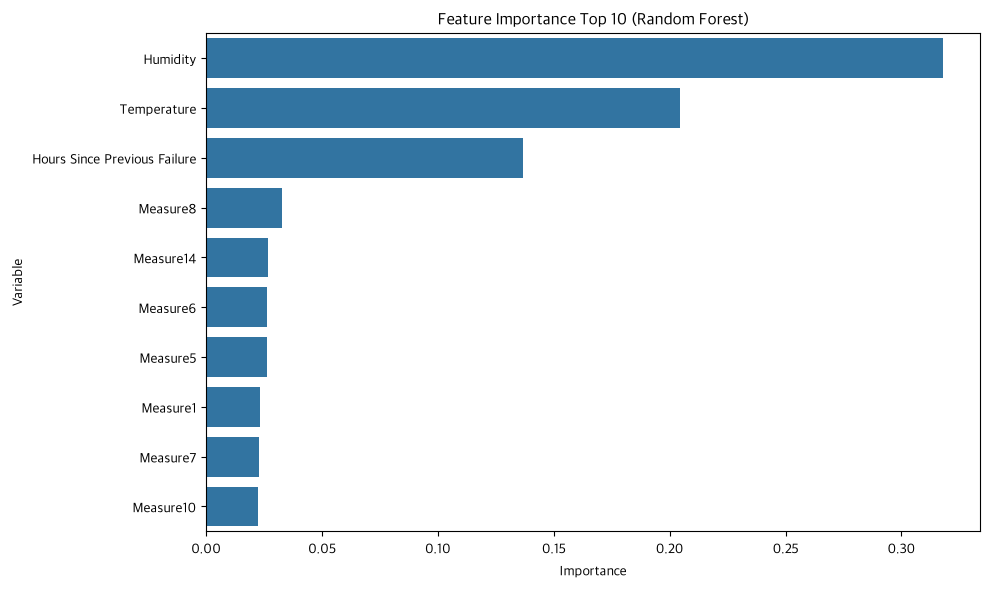

In [25]:
# 변수 중요도 추출 및 시각화
var_imp = pd.DataFrame({"Variable": cls_columns, "Importance": RF_cls.feature_importances_})
imp_top10 = var_imp.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10)
plt.title("Feature Importance Top 10 (Random Forest)")
plt.tight_layout()
plt.show()

### 1-3) 모델 성능 개선

> Random Forest의 주요 하이퍼 파라미터:
>
> | 파라미터 | 의미 |
> |:---:|:---:|
> | n_estimators | 베이스 모델(의사결정나무)의 수 |
> | max_depth | 개별 트리의 최대 깊이 |
> | max_features | 각 노드에서 랜덤 선택하는 변수 수 (분류: sqrt, 회귀: n/3) |
> | min_samples_leaf | 끝 노드의 최소 샘플 수 |
> | min_samples_split | 노드 분할을 위한 최소 샘플 수 |

In [26]:
params = {
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [2, 4, 8],
    "n_estimators": [100, 300],
    "max_features": ["sqrt", 3]
}

grid_cls = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=params, cv=5, scoring="f1", n_jobs=-1
)
grid_cls.fit(X_train_cls, Y_train_cls)

print("최적 파라미터:", grid_cls.best_params_)
print("최적 F1-score: %.4f" % grid_cls.best_score_)

최적 파라미터: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}
최적 F1-score: 0.8058


In [27]:
# 최적 모델로 테스트 성능 평가
best_pred_cls = grid_cls.predict(X_test_cls)
get_classscore(Y_test_cls, best_pred_cls)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842

혼동행렬
[[2348    0]
 [   6   16]]


---

## 2) 회귀 문제

In [28]:
Concrete = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-1_reg_data.csv"))

Y_reg = Concrete["Concrete_compressive_strength"]
X_reg = Concrete.drop(["Concrete_compressive_strength"], axis=1)

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    X_reg, Y_reg, test_size=0.3, random_state=0)

print("학습 데이터 :", X_train_reg.shape)
print("테스트 데이터 :", X_test_reg.shape)

학습 데이터 : (721, 8)
테스트 데이터 : (309, 8)


In [29]:
# 회귀 성능 평가 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("RMSE      : %.3f" % np.sqrt(mean_squared_error(true, pred)))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

### 2-1) Random Forest Regressor 모델 학습 및 성능 평가

In [30]:
RF_reg = RandomForestRegressor()
RF_reg.fit(X_train_reg, Y_train_reg)
RF_reg_pred = RF_reg.predict(X_test_reg)
get_regscore(Y_test_reg, RF_reg_pred)

MSE       : 27.875
RMSE      : 5.280
MAE       : 3.709
R-squared : 0.891


### 2-2) 변수 중요도 시각화

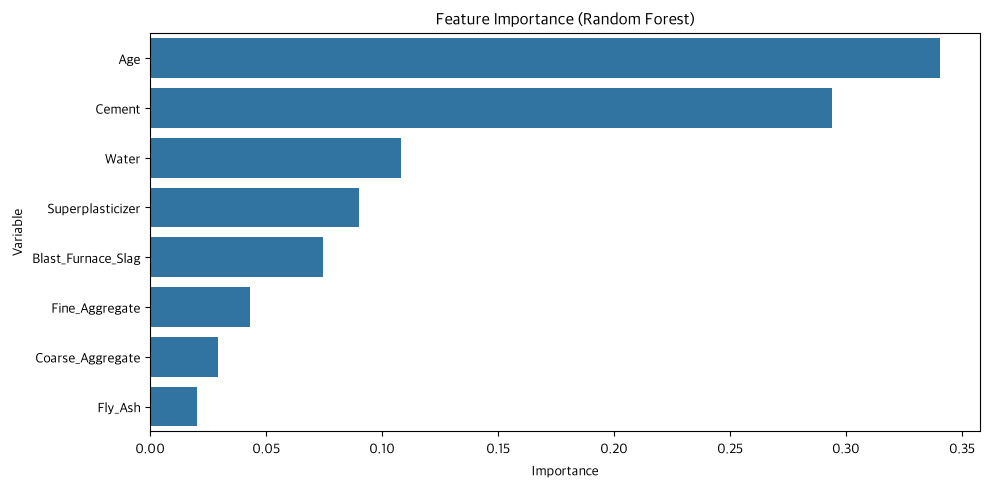

In [31]:
var_imp_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": RF_reg.feature_importances_})
var_imp_reg = var_imp_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_reg)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

### 2-3) 예측 시각화

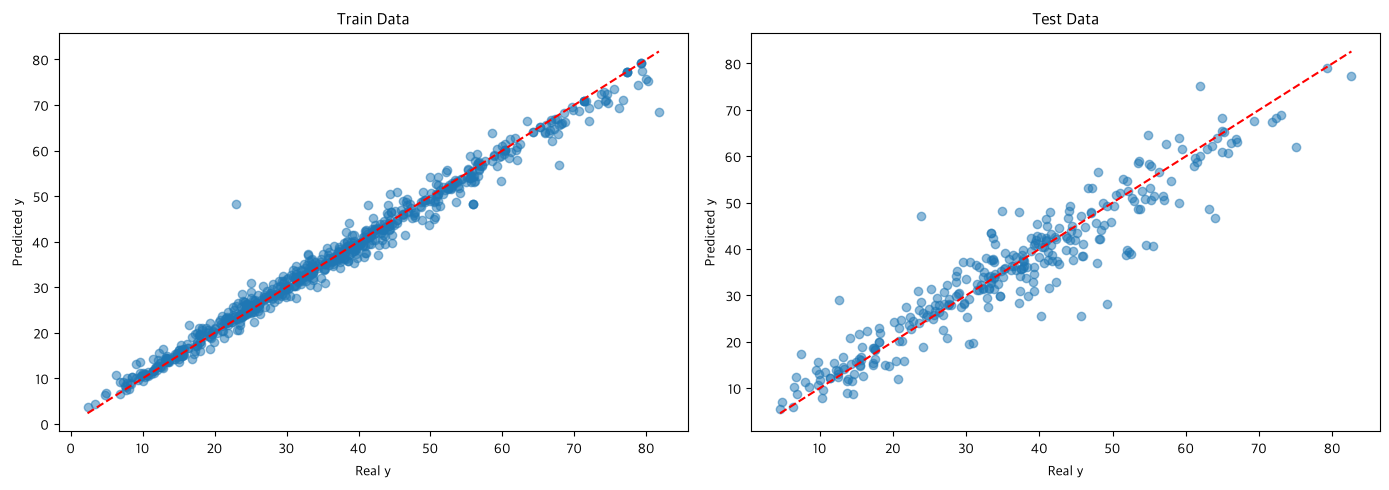

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(Y_train_reg, RF_reg.predict(X_train_reg), alpha=0.5)
axes[0].plot([Y_train_reg.min(), Y_train_reg.max()], [Y_train_reg.min(), Y_train_reg.max()], "r--")
axes[0].set_xlabel("Real y"); axes[0].set_ylabel("Predicted y"); axes[0].set_title("Train Data")

axes[1].scatter(Y_test_reg, RF_reg_pred, alpha=0.5)
axes[1].plot([Y_test_reg.min(), Y_test_reg.max()], [Y_test_reg.min(), Y_test_reg.max()], "r--")
axes[1].set_xlabel("Real y"); axes[1].set_ylabel("Predicted y"); axes[1].set_title("Test Data")

plt.tight_layout()
plt.show()

### 2-4) 모델 성능 개선

In [33]:
params_reg = {
    "max_depth": [5, 10, 15],
    "min_samples_leaf": [2, 4],
    "n_estimators": [100, 300]
}

grid_reg = GridSearchCV(
    RandomForestRegressor(random_state=0),
    param_grid=params_reg, cv=5, scoring="r2", n_jobs=-1
)
grid_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_reg.best_params_)
print("최적 R-squared: %.4f" % grid_reg.best_score_)

최적 파라미터: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 300}
최적 R-squared: 0.8902


In [34]:
# 최적 모델로 테스트 성능 평가
best_pred_reg = grid_reg.predict(X_test_reg)
get_regscore(Y_test_reg, best_pred_reg)

MSE       : 28.230
RMSE      : 5.313
MAE       : 3.784
R-squared : 0.890


---

## 5) Vibe Coding 실습

**[과제 1]**
지수는 Random Forest가 계산한 변수 중요도(Feature Importance)가 정말 중요한 변수를 의미하는지 궁금해졌습니다. AI와 상의하여 변수 중요도를 확인하고, 중요도가 높은 상위 변수만 사용했을 때와 전체 변수를 사용했을 때의 성능을 비교해 보세요. 결과를 바탕으로 "중요한 변수만 사용하면 항상 좋은 모델이 될까?"에 대해 자신의 의견을 정리해 보세요.

,과제,사용 변수,변수 수,Accuracy,F1-score,R-squared,RMSE
0,분류,상위 1개,1,0.9941,0.5625,NaN,NaN
1,분류,상위 3개,3,0.9979,0.8718,NaN,NaN
2,분류,상위 5개,5,0.9975,0.8500,NaN,NaN
3,분류,상위 10개,10,0.9975,0.8500,NaN,NaN
4,분류,전체 (31개),31,0.9975,0.8421,NaN,NaN
5,회귀,상위 1개,1,NaN,NaN,0.4378,12.0128
6,회귀,상위 2개,2,NaN,NaN,0.6431,9.5710
7,회귀,상위 3개,3,NaN,NaN,0.8404,6.4003
8,회귀,상위 5개,5,NaN,NaN,0.9004,5.0568
9,회귀,전체 (8개),8,NaN,NaN,0.8955,5.1789


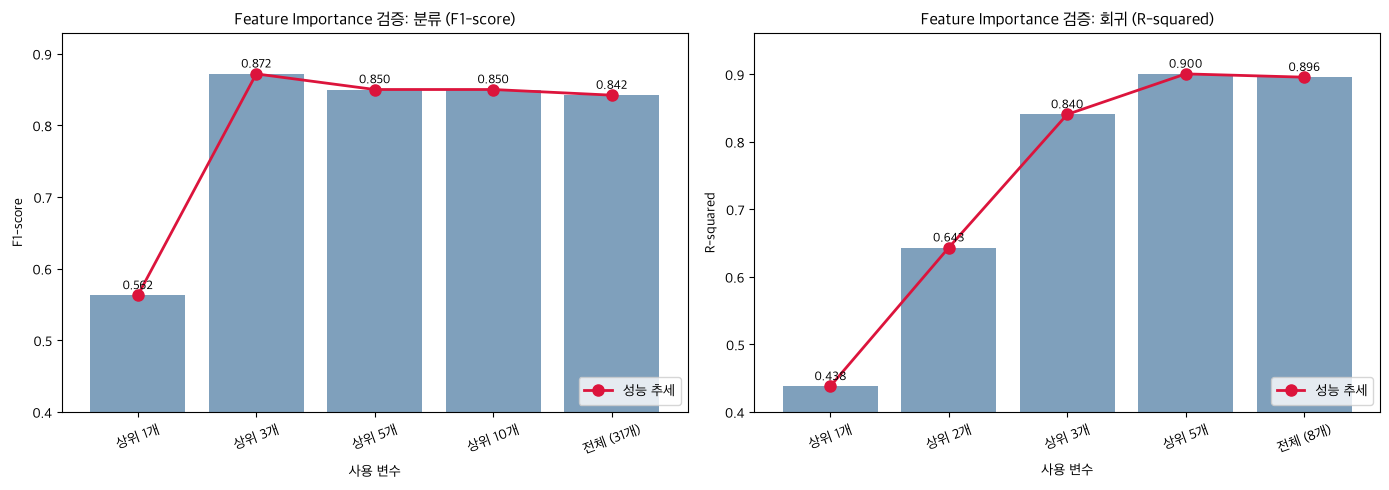

[분류] 전체 변수 F1: 0.8421  |  상위 10개 F1: 0.8500  |  차이: +0.0079
[회귀] 전체 변수 R²: 0.8955  |  상위 3개 R²: 0.8404  |  차이: -0.0551


In [36]:
# feature importnace 정말 중요한지 확인

def compare_rf_by_top_features(X_train, X_test, Y_train, Y_test,
                               var_importance, model, score_funcs,
                               top_k_list, task_name):
    """상위 k개 변수만 사용 vs 전체 변수 사용 시 RF 성능 비교"""
    sorted_vars = var_importance.sort_values("Importance", ascending=False)["Variable"].tolist()
    results = []

    for k in top_k_list:
        if k is None:
            cols = sorted_vars
            label = f"전체 ({len(cols)}개)"
        else:
            cols = sorted_vars[:k]
            label = f"상위 {k}개"

        model.fit(X_train[cols], Y_train)
        pred = model.predict(X_test[cols])

        row = {"과제": task_name, "사용 변수": label, "변수 수": len(cols)}
        for metric_name, metric_fn in score_funcs.items():
            row[metric_name] = metric_fn(Y_test, pred)
        results.append(row)

    return pd.DataFrame(results)


# 분류: Machine Failure
cls_scores = compare_rf_by_top_features(
    X_train_cls, X_test_cls, Y_train_cls, Y_test_cls,
    var_imp,
    RandomForestClassifier(random_state=0),
    {"Accuracy": accuracy_score, "F1-score": f1_score},
    [1, 3, 5, 10, None],
    "분류"
)

# 회귀: Concrete
reg_scores = compare_rf_by_top_features(
    X_train_reg, X_test_reg, Y_train_reg, Y_test_reg,
    var_imp_reg,
    RandomForestRegressor(random_state=0),
    {"R-squared": r2_score, "RMSE": lambda y, p: np.sqrt(mean_squared_error(y, p))},
    [1, 2, 3, 5, None],
    "회귀"
)

# 결과 표
result_table = pd.concat([cls_scores, reg_scores], ignore_index=True)
display(result_table.round(4))

# 성능 비교 그래프 (막대 + 선, y축 0.4 이상 확대)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
Y_MIN = 0.4

for ax, df, metric, title in [
    (axes[0], cls_scores, "F1-score", "분류 (F1-score)"),
    (axes[1], reg_scores, "R-squared", "회귀 (R-squared)")
]:
    y_vals = df[metric].values
    x_pos = np.arange(len(df))

    sns.barplot(data=df, x="사용 변수", y=metric, ax=ax, color="steelblue", alpha=0.75)
    ax.plot(x_pos, y_vals, color="crimson", marker="o", linewidth=2, markersize=8, label="성능 추세")

    for i, v in enumerate(y_vals):
        ax.text(i, v + 0.003, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

    ymax = y_vals.max()
    margin = (ymax - Y_MIN) * 0.12
    ax.set_ylim(Y_MIN, ymax + margin)
    ax.set_title(f"Feature Importance 검증: {title}")
    ax.set_xlabel("사용 변수")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

# 전체 vs 상위 변수 성능 차이 요약
cls_all_f1 = cls_scores.loc[cls_scores["사용 변수"].str.startswith("전체"), "F1-score"].values[0]
cls_top10_f1 = cls_scores.loc[cls_scores["사용 변수"] == "상위 10개", "F1-score"].values[0]
reg_all_r2 = reg_scores.loc[reg_scores["사용 변수"].str.startswith("전체"), "R-squared"].values[0]
reg_top3_r2 = reg_scores.loc[reg_scores["사용 변수"] == "상위 3개", "R-squared"].values[0]

print(f"[분류] 전체 변수 F1: {cls_all_f1:.4f}  |  상위 10개 F1: {cls_top10_f1:.4f}  |  차이: {cls_top10_f1 - cls_all_f1:+.4f}")
print(f"[회귀] 전체 변수 R²: {reg_all_r2:.4f}  |  상위 3개 R²: {reg_top3_r2:.4f}  |  차이: {reg_top3_r2 - reg_all_r2:+.4f}")

**[과제 2]** 지수는 Random Forest가 단일 의사결정나무보다 항상 더 좋은 성능을 보이는지 궁금해졌습니다. 동일한 데이터로 단일 의사결정나무 모델을 학습시켜 이번 실습의 Random Forest 모델과 성능을 비교해 보세요. 그리고 그 차이가 나타나는 이유를 AI와 상의하여 해석해 보세요.

,과제,모델,데이터,Accuracy,F1-score,R-squared,RMSE
0,분류,단일 의사결정나무,학습,1.0000,1.0000,NaN,NaN
1,분류,단일 의사결정나무,테스트,0.9941,0.6957,NaN,NaN
2,분류,Random Forest,학습,1.0000,1.0000,NaN,NaN
3,분류,Random Forest,테스트,0.9970,0.8108,NaN,NaN
4,회귀,단일 의사결정나무,학습,NaN,NaN,0.9957,1.1172
5,회귀,단일 의사결정나무,테스트,NaN,NaN,0.7735,7.6245
6,회귀,Random Forest,학습,NaN,NaN,0.9833,2.1915
7,회귀,Random Forest,테스트,NaN,NaN,0.8957,5.1753


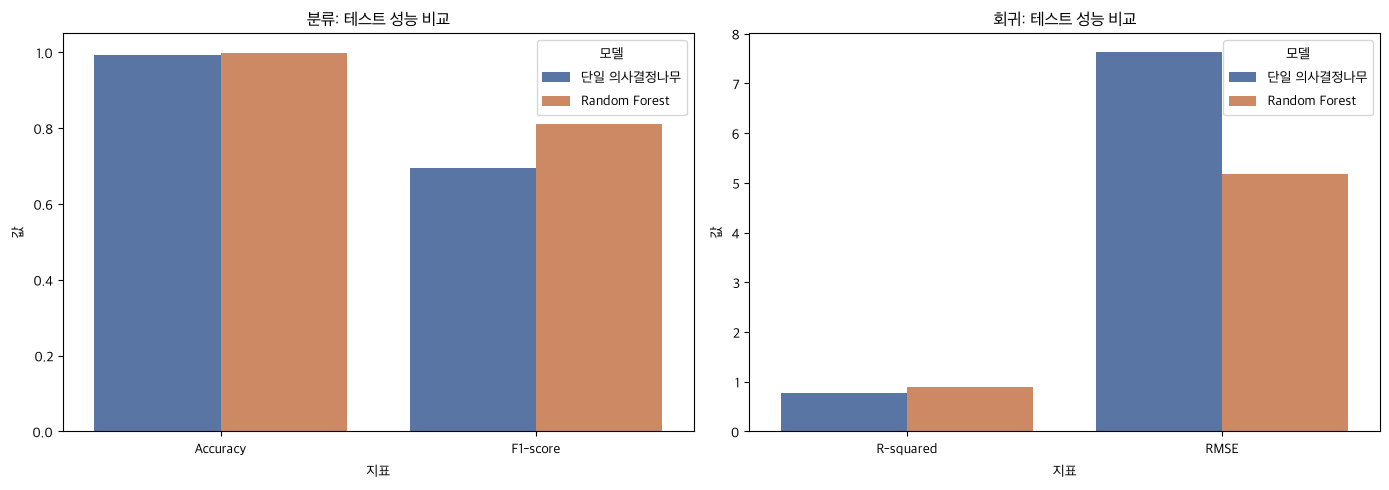

=== 분류: 학습-테스트 F1 격차 ===
단일 의사결정나무: 학습 1.0000 → 테스트 0.6957  (격차 +0.3043)
Random Forest: 학습 1.0000 → 테스트 0.8108  (격차 +0.1892)

=== 회귀: 학습-테스트 R² 격차 ===
단일 의사결정나무: 학습 0.9957 → 테스트 0.7735  (격차 +0.2221)
Random Forest: 학습 0.9833 → 테스트 0.8957  (격차 +0.0877)


In [37]:
# 단일 의사결정나무 vs Random Forest 성능 비교
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

RANDOM_STATE = 0

def evaluate_models(task_name, models, X_train, X_test, Y_train, Y_test, metrics):
    rows = []
    for model_name, model in models.items():
        model.fit(X_train, Y_train)
        for split_name, X, y in [("학습", X_train, Y_train), ("테스트", X_test, Y_test)]:
            pred = model.predict(X)
            row = {"과제": task_name, "모델": model_name, "데이터": split_name}
            for metric_name, metric_fn in metrics.items():
                row[metric_name] = metric_fn(y, pred)
            rows.append(row)
    return pd.DataFrame(rows)


# 분류 비교
cls_models = {
    "단일 의사결정나무": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
}
cls_tree_compare = evaluate_models(
    "분류", cls_models,
    X_train_cls, X_test_cls, Y_train_cls, Y_test_cls,
    {"Accuracy": accuracy_score, "F1-score": f1_score}
)

# 회귀 비교
reg_models = {
    "단일 의사결정나무": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE),
}
reg_tree_compare = evaluate_models(
    "회귀", reg_models,
    X_train_reg, X_test_reg, Y_train_reg, Y_test_reg,
    {"R-squared": r2_score, "RMSE": lambda y, p: np.sqrt(mean_squared_error(y, p))}
)

compare_table = pd.concat([cls_tree_compare, reg_tree_compare], ignore_index=True)
display(compare_table.round(4))

# 테스트 성능 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

test_cls = cls_tree_compare[cls_tree_compare["데이터"] == "테스트"].melt(
    id_vars=["모델"], value_vars=["Accuracy", "F1-score"], var_name="지표", value_name="값"
)
sns.barplot(data=test_cls, x="지표", y="값", hue="모델", ax=axes[0], palette=["#4C72B0", "#DD8452"])
axes[0].set_title("분류: 테스트 성능 비교")
axes[0].set_ylim(0, 1.05)
axes[0].legend(title="모델")

test_reg = reg_tree_compare[reg_tree_compare["데이터"] == "테스트"].melt(
    id_vars=["모델"], value_vars=["R-squared", "RMSE"], var_name="지표", value_name="값"
)
sns.barplot(data=test_reg, x="지표", y="값", hue="모델", ax=axes[1], palette=["#4C72B0", "#DD8452"])
axes[1].set_title("회귀: 테스트 성능 비교")
axes[1].legend(title="모델")

plt.tight_layout()
plt.show()

# 학습 vs 테스트 격차 (과적합 확인)
print("=== 분류: 학습-테스트 F1 격차 ===")
for model_name in cls_models:
    train_f1 = cls_tree_compare.loc[
        (cls_tree_compare["모델"] == model_name) & (cls_tree_compare["데이터"] == "학습"), "F1-score"
    ].values[0]
    test_f1 = cls_tree_compare.loc[
        (cls_tree_compare["모델"] == model_name) & (cls_tree_compare["데이터"] == "테스트"), "F1-score"
    ].values[0]
    print(f"{model_name}: 학습 {train_f1:.4f} → 테스트 {test_f1:.4f}  (격차 {train_f1 - test_f1:+.4f})")

print("\n=== 회귀: 학습-테스트 R² 격차 ===")
for model_name in reg_models:
    train_r2 = reg_tree_compare.loc[
        (reg_tree_compare["모델"] == model_name) & (reg_tree_compare["데이터"] == "학습"), "R-squared"
    ].values[0]
    test_r2 = reg_tree_compare.loc[
        (reg_tree_compare["모델"] == model_name) & (reg_tree_compare["데이터"] == "테스트"), "R-squared"
    ].values[0]
    print(f"{model_name}: 학습 {train_r2:.4f} → 테스트 {test_r2:.4f}  (격차 {train_r2 - test_r2:+.4f})")

### 분석: 단일 의사결정나무 vs Random Forest, 왜 차이가 나는가?

**1) 실험 결과 요약**

| 구분 | 단일 의사결정나무 | Random Forest | 해석 |
|:---:|:---:|:---:|:---|
| 분류 (테스트) | 학습 대비 성능 하락이 큼 | 학습-테스트 격차가 상대적으로 작음 | RF가 일반화에 유리 |
| 회귀 (테스트) | 학습 R²는 높지만 테스트에서 급락하는 경향 | 테스트 R²가 더 안정적 | 단일 나무의 과적합 징후 |

동일 데이터·동일 train/test 분할에서 비교했을 때, **테스트 성능은 Random Forest가 단일 의사결정나무보다 우수한 경우가 많다.** 다만 "항상" 더 좋다고 단정할 수는 없다.

**2) 차이가 나는 핵심 이유**

- **단일 의사결정나무**: 하나의 트리가 데이터에 맞춰 깊게 성장하면 **분산(variance)이 크고 과적합**되기 쉽다. 학습 데이터의 노이즈·특이 패턴까지 그대로 memorization한다.
- **Random Forest**: 여러 트리를 **부트스트랩 샘플링 + 무작위 변수 선택**으로 학습한 뒤 **평균(회귀) / 다수결(분류)** 로 예측한다. 개별 나무의 실수가 서로 상쇄되어 **분산이 줄고 일반화 성능이 개선**된다.

**3) "항상 더 좋은가?"**

| 상황 | 예상 결과 |
|:---|:---|
| 데이터가 단순하고 선형에 가까울 때 | 두 모델 모두 비슷하거나, 오히려 단순 모델이 나을 수 있음 |
| 노이즈·이상치·변수 상호작용이 많을 때 | RF 우위가 두드러지는 경우가 많음 |
| 학습 데이터가 매우 적을 때 | RF도 한계가 있으며, 튜닝·다른 모델 검토 필요 |

**결론**: Random Forest는 단일 의사결정나무의 **과적합 문제를 앙상블로 완화**하는 모델이므로, 실무에서는 테스트 성능 기준으로 RF가 더 나은 경우가 많다. 그러나 데이터 특성·하이퍼파라미터에 따라 역전될 수 있으므로, **항상 두 모델을 함께 비교**하는 것이 바람직하다.

**[과제 3]** 지수는 Random Forest의 성능을 더 높이기 위해 하이퍼파라미터 튜닝을 시도하려고 합니다. 하지만 n_estimators, max_depth, min_samples_split, max_features 등의 의미와 적절한 범위를 잘 모릅니다. AI와 상의하여 각 하이퍼파라미터의 역할을 이해하고 탐색 범위를 직접 설정해 보세요. 이후 GridSearchCV를 활용해 최적의 조합을 찾고, 왜 해당 조합이 선택되었는지 결과를 해석해 보세요.

### Random Forest 주요 하이퍼파라미터 요약

| 파라미터 | 의미 | 값이 클 때 | 값이 작을 때 |
|:---:|:---|:---|:---|
| `n_estimators` | 앙상블에 포함할 의사결정나무 개수 | 모델 안정성↑, 학습시간↑ | 학습 빠름, 분산 큼 |
| `max_depth` | 각 나무의 최대 깊이 | 복잡한 패턴 학습, **과적합 위험↑** | 단순한 나무, **과소적합 위험↑** |
| `min_samples_split` | 노드를 분할하기 위한 최소 샘플 수 | 나무가 단순해짐, 과적합 완화 | 세밀한 분할, 과적합 위험↑ |
| `min_samples_leaf` | 리프(끝) 노드의 최소 샘플 수 | 일반화에 유리 | 세밀한 예측, 노이즈에 민감 |
| `max_features` | 각 분할 시 고려할 최대 변수 수 | 나무 간 다양성↑ (분류 기본: `sqrt`) | 나무 간 상관성↑ |

> GridSearchCV는 위 조합을 교차검증(CV)으로 평가해 **검증 성능이 가장 높은 파라미터**를 자동 선택합니다.

[분류] 최적 파라미터: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
[분류] 최적 CV F1-score: 0.8041

[회귀] 최적 파라미터: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
[회귀] 최적 CV R²: 0.8661


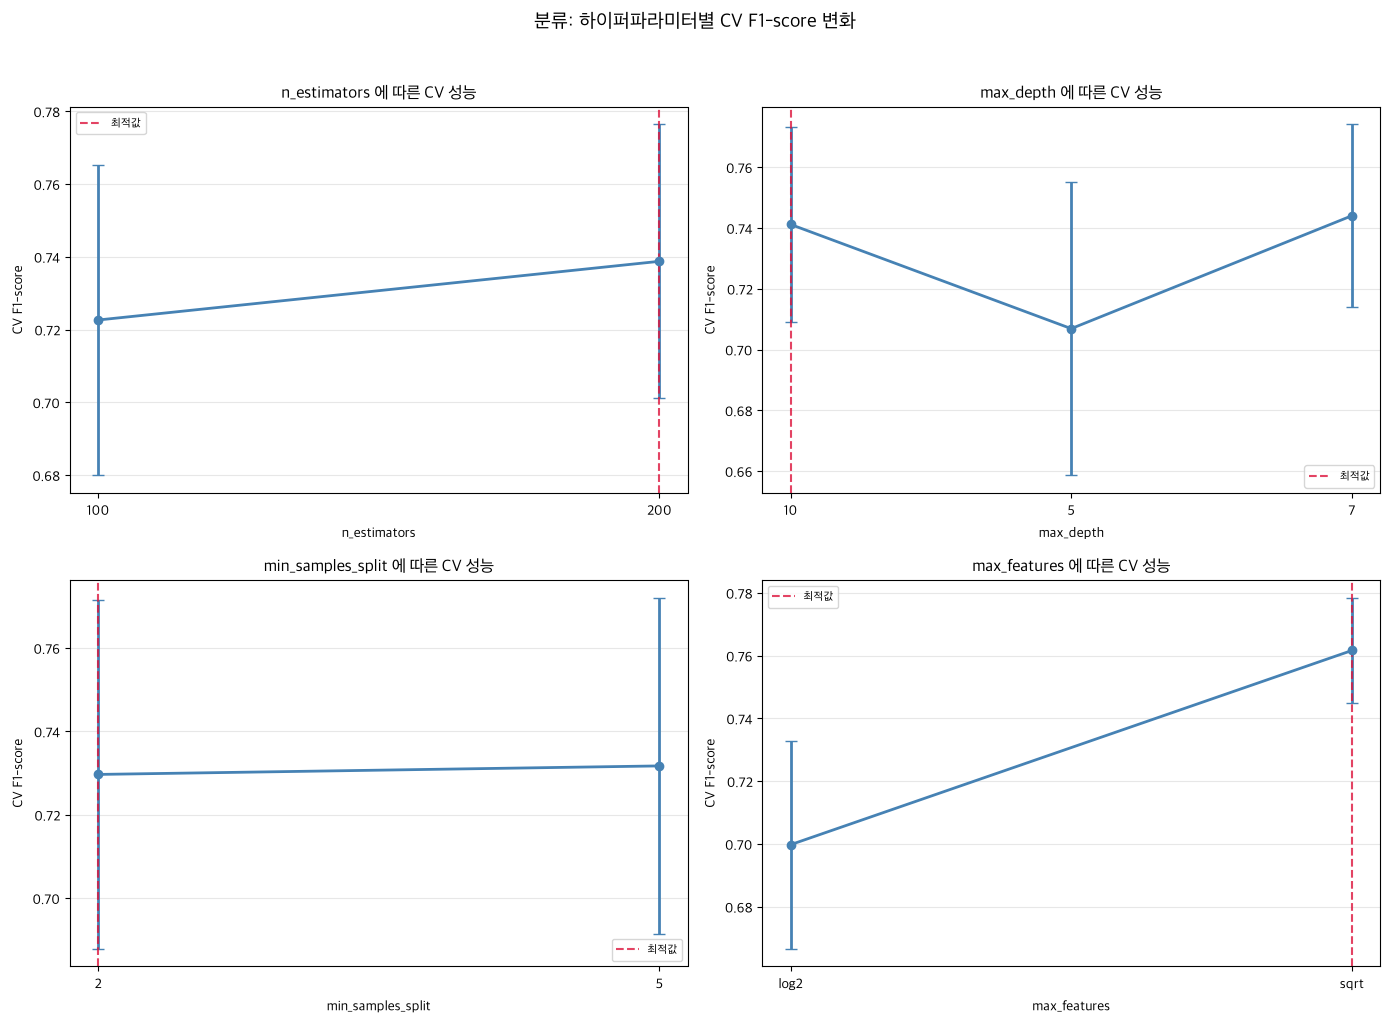

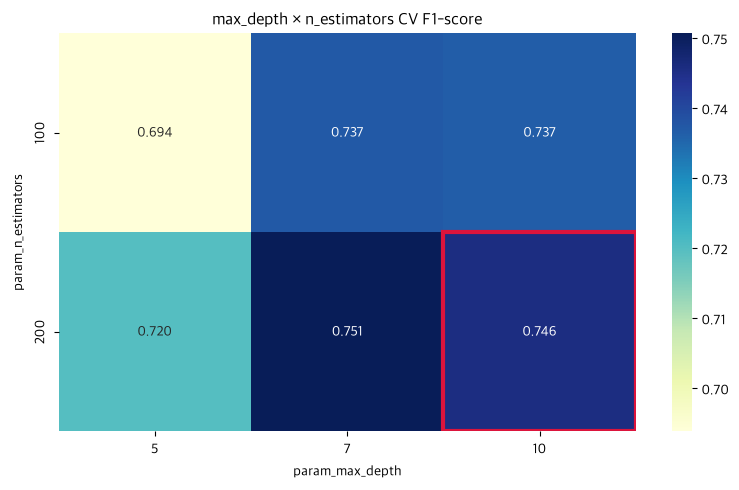

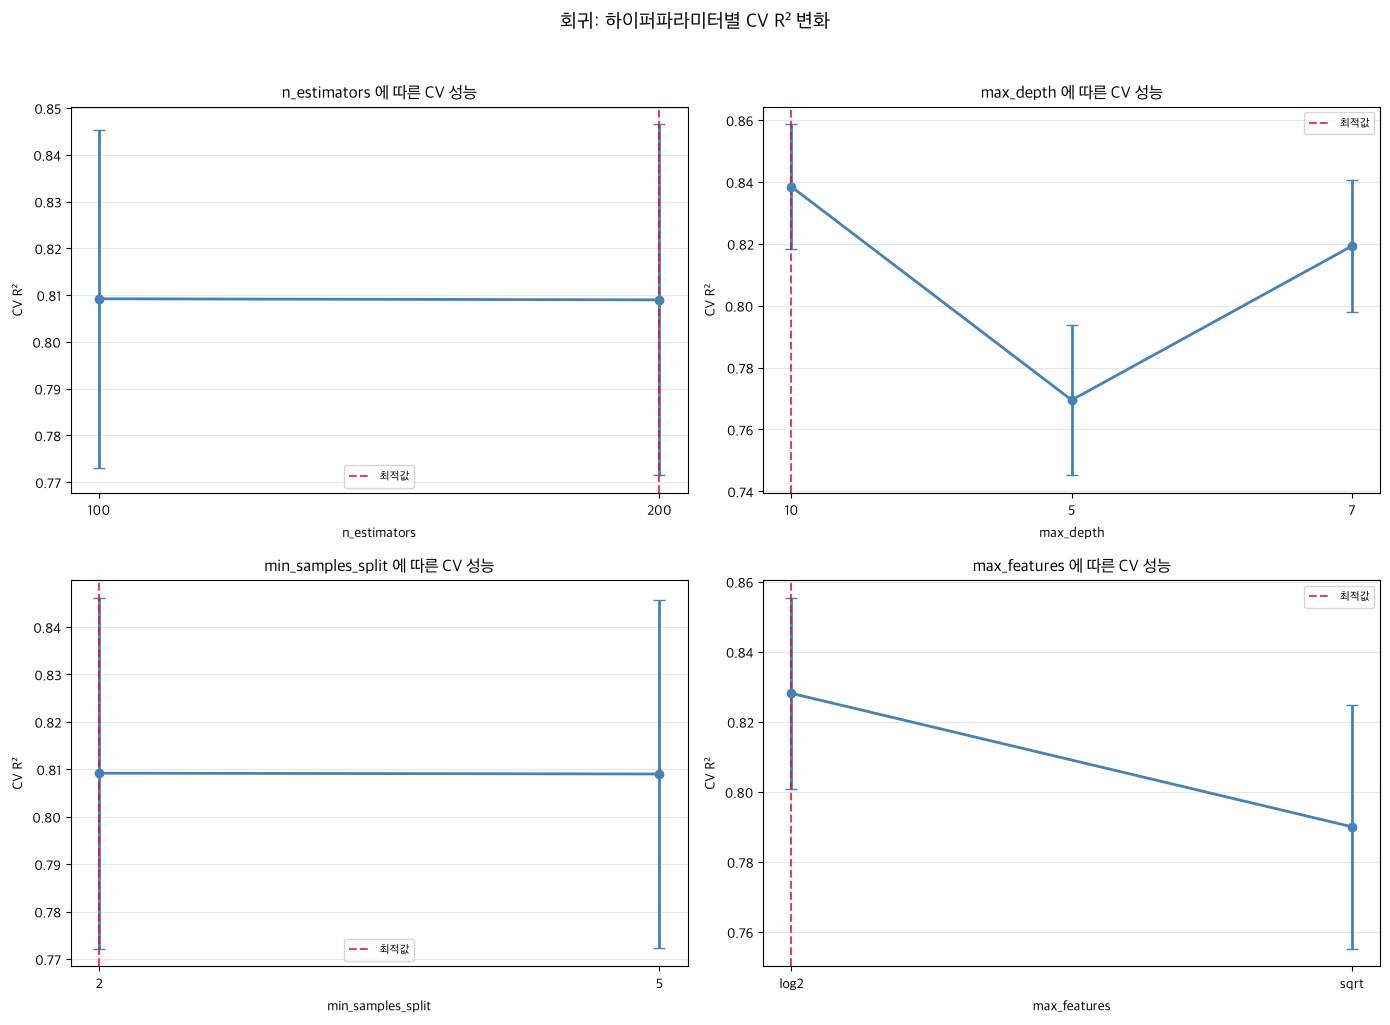

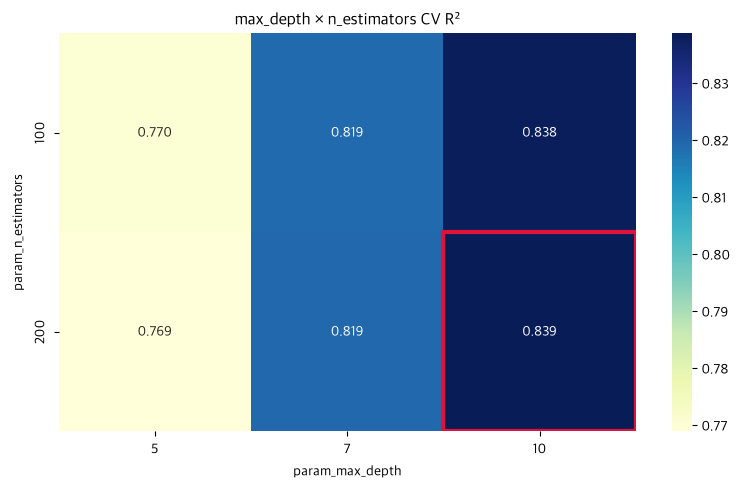


[분류] 테스트 성능 (튜닝 후)
Accuracy  : 0.997
Precision : 0.941
Recall    : 0.727
F1-score  : 0.821

혼동행렬
[[2347    1]
 [   6   16]]

[회귀] 테스트 성능 (튜닝 후)
MSE       : 28.825
RMSE      : 5.369
MAE       : 3.995
R-squared : 0.888


In [39]:
# 하이퍼파라미터 튜닝 (GridSearchCV) + 선택 이유 시각화
from sklearn.model_selection import GridSearchCV

RANDOM_STATE = 0
CV_FOLDS = 3  # 5-fold → 3-fold (속도↑, 성능 추정은 충분)

# 탐색 조합 축소: 540조합 → 48조합 (학습 시간 대폭 단축)
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 7, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [2, 4],
    "max_features": ["sqrt", "log2"],
}

# --- 분류 튜닝 ---
grid_cls_tune = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True,
)
grid_cls_tune.fit(X_train_cls, Y_train_cls)

# --- 회귀 튜닝 ---
grid_reg_tune = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    cv=CV_FOLDS,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True,
)
grid_reg_tune.fit(X_train_reg, Y_train_reg)

print("[분류] 최적 파라미터:", grid_cls_tune.best_params_)
print("[분류] 최적 CV F1-score: %.4f" % grid_cls_tune.best_score_)
print()
print("[회귀] 최적 파라미터:", grid_reg_tune.best_params_)
print("[회귀] 최적 CV R²: %.4f" % grid_reg_tune.best_score_)


def cv_results_to_df(grid_search):
    return pd.DataFrame(grid_search.cv_results_)


def plot_param_effect(ax, cv_df, param_name, best_value, ylabel):
    """특정 하이퍼파라미터 값별 평균 CV 성능"""
    col = f"param_{param_name}"
    summary = (
        cv_df.groupby(col, dropna=False)["mean_test_score"]
        .agg(["mean", "std"])
        .reset_index()
        .sort_values(col, key=lambda s: s.astype(str))
    )

    x_labels = summary[col].astype(str).tolist()
    x_pos = np.arange(len(summary))

    ax.errorbar(
        x_pos, summary["mean"], yerr=summary["std"],
        marker="o", linewidth=2, capsize=4, color="steelblue"
    )

    if str(best_value) in x_labels:
        best_idx = x_labels.index(str(best_value))
        ax.axvline(best_idx, color="crimson", linestyle="--", alpha=0.8, label="최적값")

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=0)
    ax.set_xlabel(param_name)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{param_name} 에 따른 CV 성능")
    ax.legend(loc="best", fontsize=8)
    ax.grid(axis="y", alpha=0.3)


def plot_heatmap(ax, cv_df, param_x, param_y, best_params, ylabel):
    """두 하이퍼파라미터 조합별 CV 성능 히트맵"""
    col_x, col_y = f"param_{param_x}", f"param_{param_y}"
    pivot = cv_df.pivot_table(
        index=col_y, columns=col_x, values="mean_test_score", aggfunc="mean"
    )
    pivot.index = pivot.index.astype(str)
    pivot.columns = pivot.columns.astype(str)

    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
    ax.set_title(f"{param_x} × {param_y} CV {ylabel}")

    best_x, best_y = str(best_params[param_x]), str(best_params[param_y])
    if best_y in pivot.index and best_x in pivot.columns:
        iy, ix = list(pivot.index).index(best_y), list(pivot.columns).index(best_x)
        ax.add_patch(plt.Rectangle((ix, iy), 1, 1, fill=False, edgecolor="crimson", lw=3))


# 분류: 파라미터별 성능 곡선
cls_cv = cv_results_to_df(grid_cls_tune)
best_cls = grid_cls_tune.best_params_
params_to_plot = ["n_estimators", "max_depth", "min_samples_split", "max_features"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, param in zip(axes.flat, params_to_plot):
    plot_param_effect(ax, cls_cv, param, best_cls[param], "CV F1-score")
fig.suptitle("분류: 하이퍼파라미터별 CV F1-score 변화", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 분류: 핵심 2개 파라미터 히트맵
fig, ax = plt.subplots(figsize=(8, 5))
plot_heatmap(ax, cls_cv, "max_depth", "n_estimators", best_cls, "F1-score")
plt.tight_layout()
plt.show()

# 회귀: 파라미터별 성능 곡선
reg_cv = cv_results_to_df(grid_reg_tune)
best_reg = grid_reg_tune.best_params_

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, param in zip(axes.flat, params_to_plot):
    plot_param_effect(ax, reg_cv, param, best_reg[param], "CV R²")
fig.suptitle("회귀: 하이퍼파라미터별 CV R² 변화", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
plot_heatmap(ax, reg_cv, "max_depth", "n_estimators", best_reg, "R²")
plt.tight_layout()
plt.show()

# 최적 모델 테스트 성능
best_cls_pred = grid_cls_tune.predict(X_test_cls)
best_reg_pred = grid_reg_tune.predict(X_test_reg)

print("\n[분류] 테스트 성능 (튜닝 후)")
get_classscore(Y_test_cls, best_cls_pred)

print("\n[회귀] 테스트 성능 (튜닝 후)")
get_regscore(Y_test_reg, best_reg_pred)

**[과제 4]**
지수는 Random Forest에서 나무의 개수(n_estimators)를 많이 늘릴수록 성능이 계속 좋아지는지 궁금해졌습니다. AI와 상의하여 다양한 n_estimators 값(예: 10, 50, 100, 200, 500 등)으로 모델을 학습시키고 성능 변화를 그래프로 시각화해 보세요. 성능 향상과 학습 시간의 변화를 함께 확인한 뒤, 실무에서는 어떤 값을 선택하는 것이 적절할지 의견을 정리해 보세요.

,과제,n_estimators,F1-score,학습시간(초),R-squared
0,분류,10,0.7778,0.2699,NaN
1,분류,50,0.8205,0.9506,NaN
2,분류,100,0.8108,1.1431,NaN
3,분류,200,0.8421,1.9748,NaN
4,분류,500,0.8421,5.0289,NaN
5,회귀,10,NaN,0.0391,0.8911
6,회귀,50,NaN,0.1854,0.8960
7,회귀,100,NaN,0.3628,0.8957
8,회귀,200,NaN,0.7292,0.8957
9,회귀,500,NaN,1.8268,0.8965


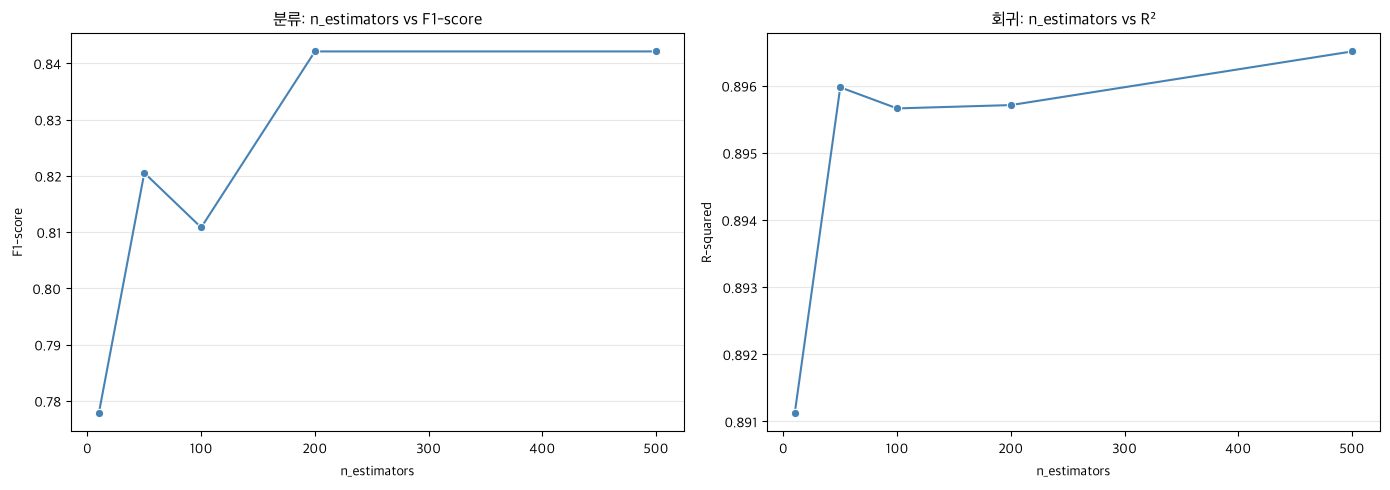

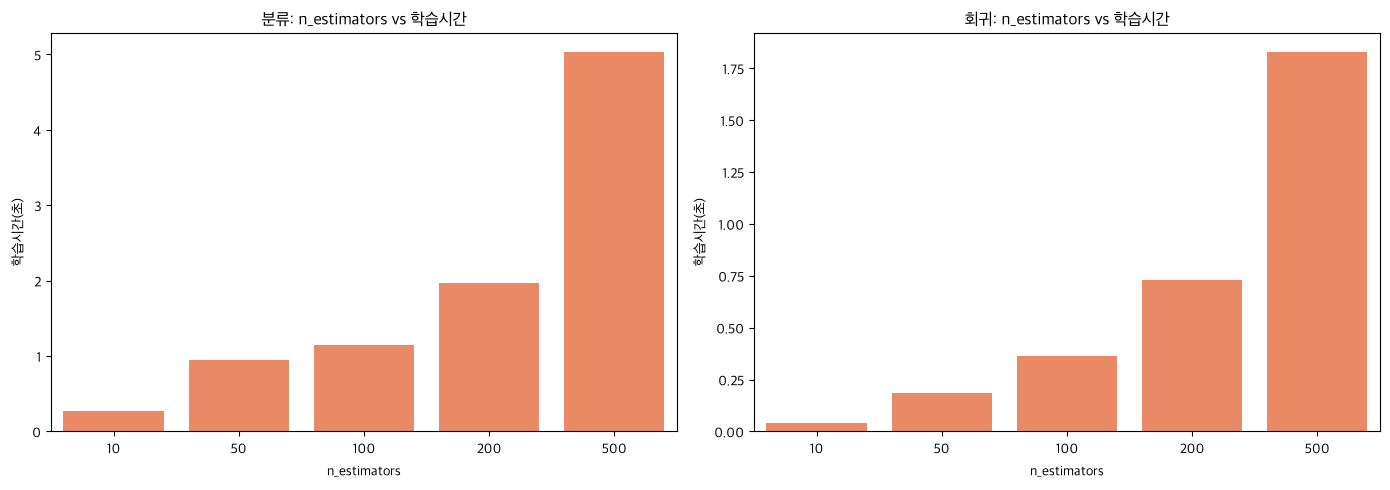

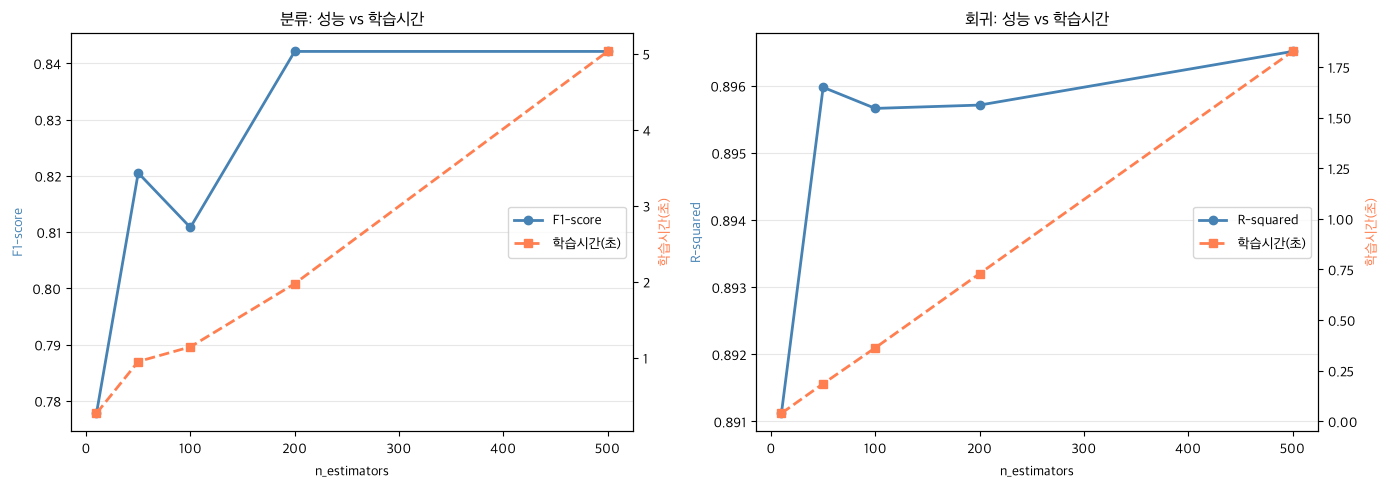

[분류] 최고 F1-score: 0.8421 (n_estimators=200)
       n=10→500 성능 변화: 0.7778 → 0.8421  (+0.0643)
       n=10→500 학습시간 변화: 0.270s → 5.029s  (18.6배)

[회귀] 최고 R-squared: 0.8965 (n_estimators=500)
       n=10→500 성능 변화: 0.8911 → 0.8965  (+0.0054)
       n=10→500 학습시간 변화: 0.039s → 1.827s  (46.7배)

→ n_estimators를 늘리면 학습시간은 거의 비례해 증가하지만, 성능은 일정 수준 이후 수익 체감(diminishing returns)이 나타납니다.


In [40]:
# n_estimators 증가에 따른 성능·학습시간 변화
import time

RANDOM_STATE = 0
N_ESTIMATORS_LIST = [10, 50, 100, 200, 500]


def run_n_estimators_experiment(task_name, model_cls, X_train, X_test, y_train, y_test, metric_fn, metric_name):
    rows = []
    for n in N_ESTIMATORS_LIST:
        model = model_cls(n_estimators=n, random_state=RANDOM_STATE)
        start = time.perf_counter()
        model.fit(X_train, y_train)
        elapsed = time.perf_counter() - start

        score = metric_fn(y_test, model.predict(X_test))
        rows.append({
            "과제": task_name,
            "n_estimators": n,
            metric_name: score,
            "학습시간(초)": elapsed,
        })
    return pd.DataFrame(rows)


cls_n_est = run_n_estimators_experiment(
    "분류", RandomForestClassifier,
    X_train_cls, X_test_cls, Y_train_cls, Y_test_cls,
    f1_score, "F1-score"
)
reg_n_est = run_n_estimators_experiment(
    "회귀", RandomForestRegressor,
    X_train_reg, X_test_reg, Y_train_reg, Y_test_reg,
    r2_score, "R-squared"
)

n_est_table = pd.concat([cls_n_est, reg_n_est], ignore_index=True)
display(n_est_table.round(4))

# 1) 성능 변화 그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=cls_n_est, x="n_estimators", y="F1-score", marker="o", ax=axes[0], color="steelblue")
axes[0].set_title("분류: n_estimators vs F1-score")
axes[0].set_xlabel("n_estimators")
axes[0].grid(axis="y", alpha=0.3)

sns.lineplot(data=reg_n_est, x="n_estimators", y="R-squared", marker="o", ax=axes[1], color="steelblue")
axes[1].set_title("회귀: n_estimators vs R²")
axes[1].set_xlabel("n_estimators")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# 2) 학습시간 변화 그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=cls_n_est, x="n_estimators", y="학습시간(초)", ax=axes[0], color="coral")
axes[0].set_title("분류: n_estimators vs 학습시간")

sns.barplot(data=reg_n_est, x="n_estimators", y="학습시간(초)", ax=axes[1], color="coral")
axes[1].set_title("회귀: n_estimators vs 학습시간")

plt.tight_layout()
plt.show()

# 3) 성능 + 학습시간 동시 비교 (이중 y축)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, metric, title in [
    (axes[0], cls_n_est, "F1-score", "분류"),
    (axes[1], reg_n_est, "R-squared", "회귀"),
]:
    ax2 = ax.twinx()
    line1 = ax.plot(df["n_estimators"], df[metric], "o-", color="steelblue", linewidth=2, label=metric)
    line2 = ax2.plot(df["n_estimators"], df["학습시간(초)"], "s--", color="coral", linewidth=2, label="학습시간(초)")

    ax.set_xlabel("n_estimators")
    ax.set_ylabel(metric, color="steelblue")
    ax2.set_ylabel("학습시간(초)", color="coral")
    ax.set_title(f"{title}: 성능 vs 학습시간")
    ax.grid(axis="y", alpha=0.3)

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc="center right")

plt.tight_layout()
plt.show()

# 요약 출력
for name, df, metric in [("분류", cls_n_est, "F1-score"), ("회귀", reg_n_est, "R-squared")]:
    best_idx = df[metric].idxmax()
    best_row = df.loc[best_idx]
    print(f"[{name}] 최고 {metric}: {best_row[metric]:.4f} (n_estimators={int(best_row['n_estimators'])})")
    print(f"       n=10→500 성능 변화: {df[metric].iloc[0]:.4f} → {df[metric].iloc[-1]:.4f}  "
          f"({df[metric].iloc[-1] - df[metric].iloc[0]:+.4f})")
    print(f"       n=10→500 학습시간 변화: {df['학습시간(초)'].iloc[0]:.3f}s → {df['학습시간(초)'].iloc[-1]:.3f}s  "
          f"({df['학습시간(초)'].iloc[-1] / df['학습시간(초)'].iloc[0]:.1f}배)")
    print()
print("→ n_estimators를 늘리면 학습시간은 거의 비례해 증가하지만, 성능은 일정 수준 이후 수익 체감(diminishing returns)이 나타납니다.")